## Setup

A dummy notebook: we load a fake sample of prompts and look at how long they are.
The numbers below are made up for demonstration.

In [1]:
import random

random.seed(42)
prompts = [random.randint(50, 3000) for _ in range(500)]
print(f"loaded {len(prompts)} prompts")

loaded 500 prompts


## Summary statistics

In [2]:
sorted_p = sorted(prompts)
{
    "min": sorted_p[0],
    "median": sorted_p[len(sorted_p) // 2],
    "p95": sorted_p[int(len(sorted_p) * 0.95)],
    "max": sorted_p[-1],
}

{'min': 52, 'median': 1528, 'p95': 2861, 'max': 2997}

In [3]:
import pandas as pd

pd.DataFrame({"bucket": ["< 500", "500–1500", "> 1500"], "count": [71, 176, 253]})

,bucket,count
0,< 500,71
1,500–1500,176
2,> 1500,253


## Distribution

Histogram of prompt lengths, in 500-token buckets:

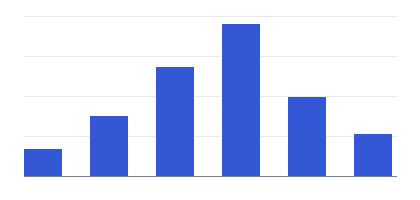

In [4]:
import matplotlib.pyplot as plt

plt.hist(prompts, bins=6)
plt.show()

## Where this fits

```mermaid
flowchart LR
    A[Raw prompts] --> B[Tokenize]
    B --> C[Bucket by length]
    C --> D[Pick context window]
```

In [5]:
assert max(prompts) < 2048, "some prompts exceed the context budget"

AssertionError: some prompts exceed the context budget